# RNA-seq Statistical Modeling — Hypothesis Testing, GLMs, and Multiple Testing

This notebook builds a working understanding of the statistics behind `DESeq2`, using **real output** from the [rnaseq-snakemake](../../pipelines/rnaseq-snakemake/) pipeline — real yeast RNA-seq data (GSE110004), comparing wild-type (`WT`) against Rap1 transcription factor depletion (`RAP1_IAA`), 3 biological replicates per group.

Three real files feed this notebook:
- `results.csv` — DESeq2's per-gene summary statistics (baseMean, log2FoldChange, pvalue, padj)
- `counts_normalized.csv` — per-sample normalized read counts, one row per gene
- `samples.tsv` — the sample sheet (sample → condition mapping)

Goal: understand *what DESeq2 is actually computing* well enough to explain it, not just read its output.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Real pipeline output, not synthetic — three files produced by the
# rnaseq-snakemake run on real yeast data (WT vs RAP1_IAA).
PIPELINE = "../../pipelines/rnaseq-snakemake/results/deseq2"

# DESeq2's per-gene summary: baseMean, log2FoldChange, pvalue, padj.
# index_col=0 makes the gene name the row index (not a plain column),
# so later code can do results.loc["YAR009C", "padj"] directly.
results = pd.read_csv(f"{PIPELINE}/results.csv", index_col=0)

# Per-sample normalized counts — one row per gene, one column per sample.
# This is the raw material Section 1/2's own hypothesis tests run on;
# results.csv alone only has DESeq2's already-computed summary stats.
counts = pd.read_csv(f"{PIPELINE}/counts_normalized.csv", index_col=0)

# The sample sheet: which sample belongs to which condition (WT/RAP1_IAA).
samples = pd.read_csv("../../pipelines/rnaseq-snakemake/config/samples.tsv", sep="\t")

# Cosmetic: name the index so it prints as "gene" instead of "Unnamed: 0".
results.index.name = "gene"
counts.index.name = "gene"

print(f"{results.shape[0]} genes tested, {counts.shape[1]} samples")
results.sort_values("padj").head()

124 genes tested, 6 samples


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
YAR010C,6980.826834,0.690559,0.095564,7.226168,4.968123e-13,2.881512e-11
YAR009C,18207.800261,0.653856,0.089741,7.286001,3.192912e-13,2.881512e-11
YAL038W,5161.043823,0.467622,0.069243,6.753364,1.444562e-11,5.585640e-10
YAL003W,702.936280,0.420813,0.107493,3.914801,9.047889e-05,2.623888e-03
YAL061W,18.380509,-1.612944,0.531703,-3.033542,2.417011e-03,5.607466e-02


In [2]:
print(results.head(5))

          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene                                                                      
HRA1      9.343098        0.123319  0.687355  0.179412  0.857615  0.998505
snR18     5.573197        0.902860  0.935128  0.965494  0.334297  0.998505
tA(UGC)A  0.000000             NaN       NaN       NaN       NaN       NaN
tL(CAA)A  0.000000             NaN       NaN       NaN       NaN       NaN
tP(UGG)A  0.201268        1.460263  4.080473  0.357866  0.720443  0.998505


In [3]:
# print(counts.head(5))

In [4]:
# print(samples.head(5))

## 1. Hypothesis Testing Refresher

For every gene, DESeq2 is answering the same question: **is this gene's expression level in `RAP1_IAA` samples different from `WT` samples, more than we'd expect from random noise between replicates alone?**

Formally, for each gene:
- **Null hypothesis (H₀):** no real difference in mean expression between conditions — any observed difference is just sampling noise.
- **Alternative hypothesis (H₁):** there is a real difference.

Two classic tests can answer this kind of question for two independent groups:

- **Independent two-sample t-test** — assumes the data in each group is roughly normally distributed. Compares the difference in group means, scaled by pooled variance.
- **Mann-Whitney U / Wilcoxon rank-sum test** — a *non-parametric* alternative: makes no assumption about the underlying distribution, works directly on ranks instead of raw values.

**Why this matters for RNA-seq specifically:** with only 3 replicates per group, there isn't nearly enough data to actually verify a normality assumption — and raw read counts are discrete, non-negative, and often right-skewed (a few highly expressed genes, many lowly expressed ones), which is a poor match for the normal distribution's assumptions to begin with. This is exactly why DESeq2 doesn't use a plain t-test — it models counts with a **negative binomial** distribution instead (Section 2). But it's worth seeing what a plain t-test and a rank-based test *would* say first, as a baseline to compare against.

In [5]:
# Split the 6 sample names into the two condition groups, using the sample
# sheet as the source of truth (same "condition" column DESeq2's own
# design formula ~condition uses).
condition_map = samples.set_index("sample")["condition"]
wt_samples = condition_map[condition_map == "WT"].index.tolist()
treated_samples = condition_map[condition_map == "RAP1_IAA"].index.tolist()

def compare_gene(gene):
    # Pull just this one gene's row, split into its two group's raw values —
    # 3 numbers per group, exactly what a real small RNA-seq experiment gives you.
    wt_vals = counts.loc[gene, wt_samples].values
    treated_vals = counts.loc[gene, treated_samples].values

    # Two-sample t-test: assumes normally-distributed data in each group.
    t_stat, t_p = stats.ttest_ind(wt_vals, treated_vals)

    # Mann-Whitney U / Wilcoxon rank-sum: no distribution assumption,
    # works on ranks instead of raw values.
    u_stat, u_p = stats.mannwhitneyu(wt_vals, treated_vals, alternative="two-sided")

    # DESeq2's own numbers for the same gene, for direct comparison.
    return pd.Series({
        "WT_mean": wt_vals.mean(),
        "RAP1_IAA_mean": treated_vals.mean(),
        "t_test_p": t_p,
        "wilcoxon_p": u_p,
        "DESeq2_p": results.loc[gene, "pvalue"],
        "DESeq2_padj": results.loc[gene, "padj"],
    })

# One gene DESeq2 called highly significant, one it called not significant at all —
# run compare_gene() on each and stack the results into one table.
example_genes = ["YAR009C", "YAL005C"]
comparison = pd.DataFrame({g: compare_gene(g) for g in example_genes}).T
comparison

,WT_mean,RAP1_IAA_mean,t_test_p,wilcoxon_p,DESeq2_p,DESeq2_padj
YAR009C,22265.201655,14150.398866,0.008498,0.1,3.192912e-13,2.881512e-11
YAL005C,4817.069424,5039.140606,0.333638,0.4,3.910918e-01,9.985048e-01


**Look at the table above.** All three methods (t-test, Wilcoxon, DESeq2) should broadly agree on *which* gene looks different between conditions and which doesn't — that agreement itself is a useful sanity check. But also notice: with only n=3 per group, a plain Wilcoxon rank-sum test has very limited resolution (there are only $\binom{6}{3}=20$ possible ways to split 6 values into two groups of 3, so its smallest possible p-value is mechanically bounded — it literally cannot report a p-value as small as DESeq2's). This is a genuine, practical reason RNA-seq analysis doesn't just run one test per gene with `scipy` and call it done — it needs a model built specifically for small-sample, discrete count data. That model is the negative binomial GLM, covered next.

## 2. The Negative Binomial GLM — What DESeq2 Actually Fits

RNA-seq read counts are discrete, non-negative integers — a poor fit for a normal-distribution t-test's assumptions. The natural first choice for count data is the **Poisson distribution** — but Poisson has a restrictive property: variance always equals the mean, exactly, by definition. Real biological replicates practically always show **more variance than that** (*overdispersion*) — no two yeast cultures behave identically even under the same condition, adding real biological variability on top of pure counting noise.

The **negative binomial distribution** generalizes Poisson with one extra parameter, dispersion ($\alpha$), that explicitly models this extra variance:

$$\text{Var}(\text{count}) = \mu + \alpha \mu^2$$

where $\mu$ is the mean count. When $\alpha = 0$, this collapses back to Poisson exactly. DESeq2 fits, for every gene, a **generalized linear model (GLM)**:

$$\log(\mu) = \beta_0 + \beta_1 \cdot \text{condition}$$

a log link connecting the linear predictor to the mean count, where $\beta_1$ — the coefficient on `condition` — is directly the **log fold change** already seen in `results.csv` (natural log; DESeq2 reports it converted to log2).

Let's fit this ourselves, from scratch, for `YAR009C` — using only that one gene's 6 real count values, with no cross-gene borrowing this time — and compare the result against both Section 1's naive tests and DESeq2's actual (shrinkage-informed) fit.

In [6]:
import statsmodels.api as sm

def fit_nb_glm(gene):
    df = samples.copy()
    # Attach this one gene's 6 count values onto the sample sheet, so each
    # row is (sample, condition, count) — the shape a regression needs.
    df["count"] = counts.loc[gene, df["sample"]].values

    # DESeq2 (via R's factor()) orders levels alphabetically, making RAP1_IAA
    # the reference level here ("R" < "W") — match that explicitly so our
    # coefficient's sign lines up with DESeq2's log2FoldChange directly.
    df["condition"] = pd.Categorical(df["condition"], categories=["RAP1_IAA", "WT"])

    # Turn the condition column into a 0/1 indicator: drop_first=True drops
    # the reference level (RAP1_IAA), leaving one column named "WT"
    # (1 = WT sample, 0 = RAP1_IAA sample) — this becomes beta_1 in the model.
    X = pd.get_dummies(df["condition"], drop_first=True).astype(float)
    X = sm.add_constant(X)  # adds the intercept column (beta_0)
    y = df["count"]

    # Fit log(count) = beta_0 + beta_1*WT as a negative binomial GLM.
    # disp=0 just silences the optimizer's convergence printout.
    fit = sm.NegativeBinomial(y, X).fit(disp=0)

    return pd.Series({
        "baseMean": results.loc[gene, "baseMean"],
        # fit.params["WT"] is beta_1 in natural-log units; DESeq2 reports
        # log2, so divide by ln(2) to convert onto the same scale.
        "our_NB_log2FC": fit.params["WT"] / np.log(2),
        "our_NB_pvalue": fit.pvalues["WT"],
        # statsmodels' NegativeBinomial estimates alpha (dispersion) jointly
        # with the coefficients via maximum likelihood — no cross-gene
        # information used, unlike DESeq2's shrinkage-based estimate.
        "our_NB_alpha": fit.params["alpha"],
        "DESeq2_log2FC": results.loc[gene, "log2FoldChange"],
        "DESeq2_pvalue": results.loc[gene, "pvalue"],
    })

# Deliberately spread across baseMean, not just DESeq2's top hit: a strong
# high-count gene, a moderate significant one, and a borderline low-count
# one — so the shrinkage comparison isn't resting on a single cherry-picked
# example.
example_genes = ["YAR009C", "YAL003W", "YAL061W"]
glm_comparison = pd.DataFrame({g: fit_nb_glm(g) for g in example_genes}).T
glm_comparison

,baseMean,our_NB_log2FC,our_NB_pvalue,our_NB_alpha,DESeq2_log2FC,DESeq2_pvalue
YAR009C,18207.800261,0.653948,9.119594e-13,0.005982,0.653856,3.192912e-13
YAL003W,702.936280,0.420167,3.316054e-09,0.002183,0.420813,9.047889e-05
YAL061W,18.380509,-1.615379,4.091942e-06,0.015302,-1.612944,2.417011e-03


**What actually happens here, from the real numbers** (worth noting: the opposite of a natural first guess, corrected below): for `YAL003W` and `YAL061W`, our from-scratch fit is *dramatically more* "significant" than DESeq2 — not weaker. Only `YAR009C` (both p-values astronomically tiny either way) is close.

**Why:** maximum-likelihood estimates of a dispersion parameter from very few data points (n=3 per group) are systematically **biased toward underestimating** true variability — the same general phenomenon behind sample variance dividing by n−1 instead of n. An underestimated dispersion makes a model think the data is cleaner than it really is, producing p-values that are too small — the naive fit is *overconfident*, not just noisy.

DESeq2's empirical Bayes shrinkage exists specifically to correct this: it pulls each gene's likely-too-low naive dispersion estimate up toward the more reliable, dataset-wide trend, making DESeq2 appropriately **more conservative** than a naive per-gene fit — not more powerful, which is the easy but wrong intuition. This is the actual historical motivation for shrinkage-based methods in genomics (DESeq2, edgeR, limma's eBayes): early per-gene-only analyses were notorious for producing floods of false positives, precisely because small-sample dispersion estimates run overconfident by default. Shrinkage exists to prevent that, not to manufacture extra significance.

Compare `our_NB_alpha` against how confident each p-value is: the smaller our naive alpha, the more overconfident our test — and DESeq2's shrinkage correction shows up largest exactly where the naive estimate is furthest from realistic.

## 3. Multiple Testing Correction — Why RNA-seq Can't Use Raw p-values

Every gene tested is one independent statistical test. With 124 genes tested at the conventional threshold α = 0.05, **pure chance alone** predicts about 124 × 0.05 ≈ 6 genes would look "significant" even if RAP1 depletion had *zero* real effect anywhere — 5% of independent tests cross the threshold by luck alone, by definition. Real experiments often test thousands to tens of thousands of genes, where that "chance alone" count climbs into the hundreds. Raw p-values, used naively across many simultaneous tests, systematically overstate how many real findings you actually have.

In [7]:
# Only count genes that actually got tested — a few genes had zero reads in
# every sample (see the tA(UGC)A / tL(CAA)A NaN rows earlier), and DESeq2
# leaves their pvalue as NaN rather than testing them.
n_genes = results["pvalue"].notna().sum()

# If every gene's true effect were exactly zero, we'd still expect 5% of
# n_genes tests to cross p < 0.05 purely from random sampling noise —
# that's the literal definition of a 0.05 significance threshold.
expected_by_chance = n_genes * 0.05

raw_sig = (results["pvalue"] < 0.05).sum()          # naive, uncorrected count
adj_sig = (results["padj"] < 0.05).sum()             # DESeq2's BH-corrected count

pd.Series({
    "genes tested": n_genes,
    "expected 'significant' by chance alone (n x 0.05)": expected_by_chance,
    "genes with raw pvalue < 0.05": raw_sig,
    "genes with BH-adjusted padj < 0.05": adj_sig,
})

genes tested                                         116.0
expected 'significant' by chance alone (n x 0.05)      5.8
genes with raw pvalue < 0.05                           9.0
genes with BH-adjusted padj < 0.05                     4.0
dtype: float64

Two classic corrections address this, with very different philosophies:

- **Bonferroni correction** — controls the *family-wise error rate* (FWER): the probability of making **even one** false positive across all tests. Simple but blunt: divide α by the number of tests (α/n), equivalent to multiplying every p-value by n. Extremely conservative once n is in the thousands — real experiments testing 20,000+ genes would need a p-value smaller than 0.05/20000 = 0.0000025 just to pass, strict enough to miss most true findings.

- **Benjamini-Hochberg (BH) / False Discovery Rate (FDR)** — a fundamentally different question: instead of "what's the chance of *any* false positive across everything," it controls "of the genes I call significant, what *fraction* are expected to be false positives?" Setting `padj < 0.05` means: among everything called significant, on average 5% might be false positives — a controlled, known error *rate*, not zero errors. This tradeoff is what makes it practical for genomics: accept a small, quantified false-positive rate in exchange for actually being able to detect real effects at all.

`padj` in `results.csv` is DESeq2's BH-corrected value. Let's implement BH from scratch and confirm it reproduces DESeq2's own numbers.

In [8]:
def benjamini_hochberg(pvalues):
    pvalues = pvalues.dropna()          # skip untested genes (NaN pvalue)
    n = len(pvalues)

    # Step 1: sort p-values smallest to largest — BH is defined in terms
    # of each p-value's *rank* among all the others, not its raw value alone.
    ranked = pvalues.sort_values()
    ranks = np.arange(1, n + 1)         # 1, 2, 3, ..., n — rank of each sorted p-value

    # Step 2: the core BH formula — scale each p-value by (total tests / its rank).
    # The smallest p-value (rank 1) gets scaled up the most; the largest
    # (rank n) is left roughly as-is. This is what makes BH less strict
    # than Bonferroni (which scales every p-value by n, not n/rank).
    bh = ranked.values * n / ranks

    # Step 3: enforce monotonicity. Raw BH values aren't guaranteed to be
    # non-decreasing as you move to larger raw p-values, which wouldn't
    # make sense for an "adjusted p-value" — so walk from the largest
    # p-value down to the smallest, taking a running minimum. Reversing
    # twice ([::-1]) applies the running-min back-to-front, then flips
    # the result back to the original (ascending) order.
    bh = np.minimum.accumulate(bh[::-1])[::-1]

    bh = np.clip(bh, 0, 1)              # adjusted p-values can't exceed 1
    return pd.Series(bh, index=ranked.index)

our_padj = benjamini_hochberg(results["pvalue"])

# Compare our from-scratch values against DESeq2's own padj column,
# reindexed to the same gene order for a clean side-by-side.
check = pd.DataFrame({
    "our_BH_padj": our_padj,
    "DESeq2_padj": results.loc[our_padj.index, "padj"],
})
check["difference"] = (check["our_BH_padj"] - check["DESeq2_padj"]).abs()
check.sort_values("DESeq2_padj").head(10)

,our_BH_padj,DESeq2_padj,difference
gene,,,
YAR009C,2.881512e-11,2.881512e-11,2.584939e-26
YAR010C,2.881512e-11,2.881512e-11,2.584939e-26
YAL038W,5.585640e-10,5.585640e-10,4.135903e-25
YAL003W,2.623888e-03,2.623888e-03,1.561251e-17
YAL061W,5.607466e-02,5.607466e-02,9.992007e-16
YAL037C-B,6.089428e-02,6.089428e-02,1.387779e-16
YAL035W,1.428429e-01,1.428429e-01,1.304512e-15
YAL017W,2.744232e-01,2.744232e-01,1.665335e-16
YAL012W,5.268263e-01,5.268263e-01,2.220446e-16


`difference` should be at (or extremely near) zero for every gene — unlike the GLM section, BH correction is a fully deterministic algorithm computed directly from the p-values, no model-fitting or estimation involved, so reproducing it exactly is expected here, not a coincidence.

One more comparison worth seeing directly — how much more conservative Bonferroni would be on this same data:

In [9]:
# Bonferroni: divide alpha by the number of tests, rather than scaling by
# rank the way BH does — every gene gets the same strict cutoff regardless
# of how it ranks among the others.
bonferroni_sig = (results["pvalue"] < 0.05 / n_genes).sum()

pd.Series({
    "significant at raw p < 0.05": raw_sig,
    "significant at BH padj < 0.05": adj_sig,
    "significant at Bonferroni-corrected p < 0.05": bonferroni_sig,
})

significant at raw p < 0.05                     9
significant at BH padj < 0.05                   4
significant at Bonferroni-corrected p < 0.05    4
dtype: int64

On this dataset the gap between BH and Bonferroni is modest — only 124 genes tested, and the real hits here have unusually strong effects. Scale this up to a real experiment testing 20,000+ human genes, and Bonferroni's strictness routinely eliminates genuine, moderate-effect genes that BH correctly keeps — the gap widens dramatically with test count, not effect size. This is exactly why essentially every RNA-seq differential expression tool (DESeq2, edgeR, limma) reports BH/FDR-adjusted p-values by default, not Bonferroni-adjusted ones.

## 4. PCA & Clustering — Sample-Level QC

Every section so far worked *per-gene* — is this one gene different between conditions? PCA and clustering ask the opposite question: **looking at every gene at once, how do the *samples themselves* relate to each other?** This is squarely a QC question, not a differential expression one — before trusting any per-gene result, you want to know whether replicates of the same condition actually resemble each other, and whether any sample looks like an outlier that doesn't fit its group.

The pipeline's own DESeq2 script already produced a PCA plot (`pca.png`, via R's `plotPCA()`), which you've already seen. Let's build the same thing from scratch here, in Python, to see exactly what PCA is doing mathematically — not just call a library function and trust the picture.

Each sample can be thought of as a single point in a very high-dimensional space — one dimension per gene (124 here; a real experiment might have 20,000+). Genes with correlated expression patterns across samples make that space highly redundant — you don't actually need 124 independent numbers to describe most of the meaningful variation between 6 samples.

**Principal Component Analysis (PCA)** finds new axes — linear combinations of the original genes — ordered by how much of the total variance across samples each one explains. PC1 captures the single direction of greatest variation between samples; PC2 the next largest direction *uncorrelated* with PC1; and so on. Plotting samples on just PC1 vs PC2 is a compressed, 2D summary of however-many-dimensional reality, chosen specifically to preserve as much of the real variation as a 2D plot possibly can.

Under the hood, PCA is just an eigendecomposition of the centered data — equivalently, a Singular Value Decomposition (SVD). No black box.

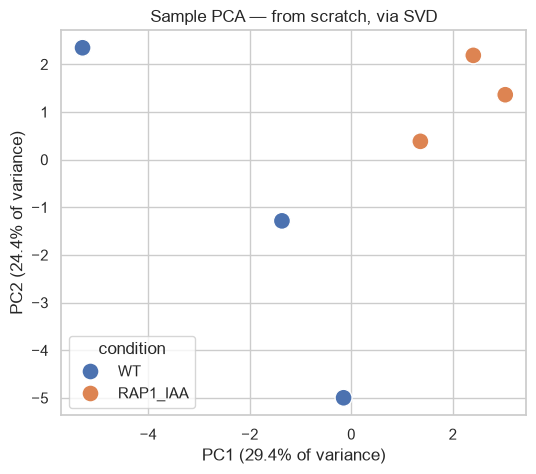

,PC1,PC2,sample,condition,fq1,fq2
0,-5.292468,2.346881,WT_REP1,WT,resources/reads/WT_REP1_R1.fastq.gz,resources/reads/WT_REP1_R2.fastq.gz
1,-0.149609,-4.995674,WT_REP2,WT,resources/reads/WT_REP2_R1.fastq.gz,resources/reads/WT_REP2_R2.fastq.gz
2,-1.363670,-1.284389,WT_REP3,WT,resources/reads/WT_REP3_R1.fastq.gz,resources/reads/WT_REP3_R2.fastq.gz
3,3.035740,1.361866,RAP1_IAA_REP1,RAP1_IAA,resources/reads/RAP1_IAA_REP1_R1.fastq.gz,resources/reads/RAP1_IAA_REP1_R2.fastq.gz
4,1.363460,0.383812,RAP1_IAA_REP2,RAP1_IAA,resources/reads/RAP1_IAA_REP2_R1.fastq.gz,resources/reads/RAP1_IAA_REP2_R2.fastq.gz
5,2.406546,2.187505,RAP1_IAA_REP3,RAP1_IAA,resources/reads/RAP1_IAA_REP3_R1.fastq.gz,resources/reads/RAP1_IAA_REP3_R2.fastq.gz


In [10]:
# log2 transform: same stabilizing idea as vst()/varianceStabilizingTransformation()
# in the R script — compresses the huge dynamic range of raw counts (a few
# genes in the thousands, most under 100) onto a scale where "distance"
# between samples is more meaningful for PCA.
log_counts = np.log2(counts + 1)

# PCA operates on samples as rows, genes as columns — counts is genes x
# samples, so transpose.
X = log_counts.T.values  # shape: (6 samples, 124 genes)

# Center each gene to mean zero across samples — PCA is defined in terms of
# variance around the mean, not raw magnitude.
X_centered = X - X.mean(axis=0)

# Singular Value Decomposition: X_centered = U @ diag(S) @ Vt.
# U's columns are the principal component *scores* (one value per sample,
# per component); S (the singular values) relates directly to how much
# variance each component explains.
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
pc_scores = U * S

# Fraction of total variance each component explains.
var_explained = (S ** 2) / np.sum(S ** 2)

pca_df = pd.DataFrame({
    "PC1": pc_scores[:, 0],
    "PC2": pc_scores[:, 1],
    "sample": log_counts.columns,
}).merge(samples, on="sample")

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="condition", s=150, ax=ax)
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% of variance)")
ax.set_title("Sample PCA — from scratch, via SVD")
plt.show()

pca_df

**What to check:** do the two conditions separate cleanly along PC1 (or whichever component explains the most variance)? If replicates of the same condition cluster tightly together and away from the other condition, that's a strong, *independent* piece of evidence supporting the DESeq2 differential expression results — it means the single biggest source of variation in the whole dataset is the experimental condition itself, not some other confound (batch effects, sample quality, mislabeling).

Compare this to `pca.png` from the pipeline — it should look very similar in *shape* (same separation pattern), though not necessarily identical in scale: R's `plotPCA()` uses `varianceStabilizingTransformation()` rather than a plain log2, a related but not identical scaling choice.

### Sample-to-sample clustering

PCA finds axes of variance across all samples simultaneously. A simpler, complementary QC check: how correlated is each sample with every other sample, directly? Samples from the same condition should correlate strongly with each other; a true outlier sample (contamination, mislabeling, a failed prep) would show up as one that doesn't correlate well with anyone — including its own supposed replicates.

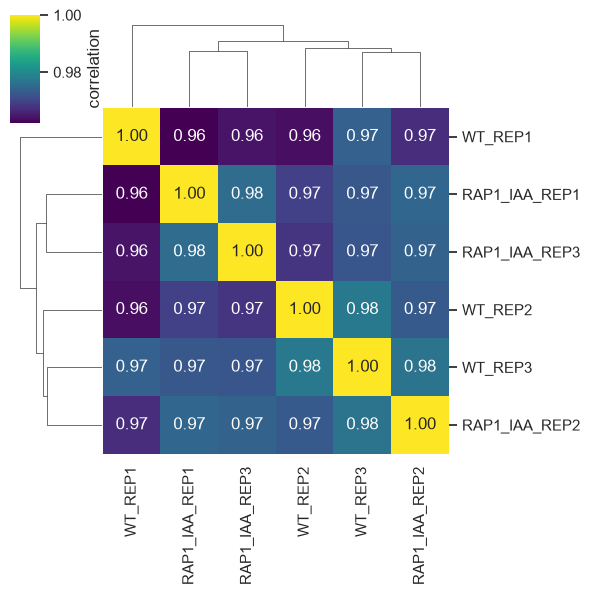

In [11]:
# Pairwise correlation between every sample's log2 expression profile —
# .corr() on a DataFrame correlates columns against each other, and
# log_counts' columns are samples (genes are rows), exactly what we want.
corr = log_counts.corr()

# clustermap draws the correlation heatmap AND a hierarchical clustering
# dendrogram along each axis in one call — the dendrogram groups samples by
# similarity, reordering rows/columns so similar samples sit next to
# each other rather than in their original sample-sheet order.
sns.clustermap(
    corr, annot=True, fmt=".2f", cmap="viridis",
    figsize=(6, 6), cbar_kws={"label": "correlation"},
)
plt.show()

**What actually happens here** (worth correcting against the prediction above, not glossing over): the dendrogram does *not* cleanly separate `WT` from `RAP1_IAA` — `RAP1_IAA_REP2` clusters most closely with `WT_REP3` (0.98 correlation), not with its own condition's replicates. This disagrees with the PCA plot, which separated the two conditions perfectly.

**Why they disagree:** plain correlation weighs every one of the 124 genes equally — including the ~120 genes with no real difference between conditions at all. Those non-differential genes dominate the correlation number by sheer count, diluting the real signal carried by only a handful of truly differential genes (`YAR009C`, `YAR010C`, `YAL038W`, `YAL003W`). PCA behaves differently by construction: it explicitly finds the direction of *maximum variance* across samples, which naturally up-weights the genes that vary the most between conditions — largely the real DE genes — rather than treating every gene as equally informative. That's a structural reason PCA is better suited than raw whole-transcriptome correlation for detecting a condition effect carried by only a small fraction of genes, not a quirk of this particular dataset.

**The actual, more accurate takeaway:** these two methods don't automatically agree, and when they don't, it's informative *why* — a technique's sensitivity depends on what it implicitly weighs. A true outlier sample (bad prep, contamination) would likely show up as low correlation with *everyone*, which isn't what's happening here — every pairwise correlation sits in a narrow 0.96–0.98 band, so this isn't a QC failure, just two methods with different sensitivity to a subtle, minority-of-genes effect.

---

That closes out the statistical modeling module: hypothesis testing fundamentals, the negative binomial GLM DESeq2 actually fits, why and how multiple testing correction works, and sample-level QC via PCA and clustering — all built from scratch and checked against real DESeq2 output from real yeast RNA-seq data, including the places where two reasonable methods turned out to disagree.

## 5. Standard Differential Expression Visualizations

Three plots that show up in essentially every RNA-seq paper and report — worth building all three from the same `results.csv` already in hand.

### MA Plot

Mean expression (`baseMean`, x-axis, log-scaled) vs log2 fold change (y-axis). "MA" is inherited terminology from microarrays (M = log ratio, A = average intensity), but the plot carries over to RNA-seq unchanged. Useful as a quick visual QC: fold-change estimates for low-count genes are naturally noisier (more scatter on the left side of the plot) — the same reason DESeq2's shrinkage matters most for low-count genes in Section 2.

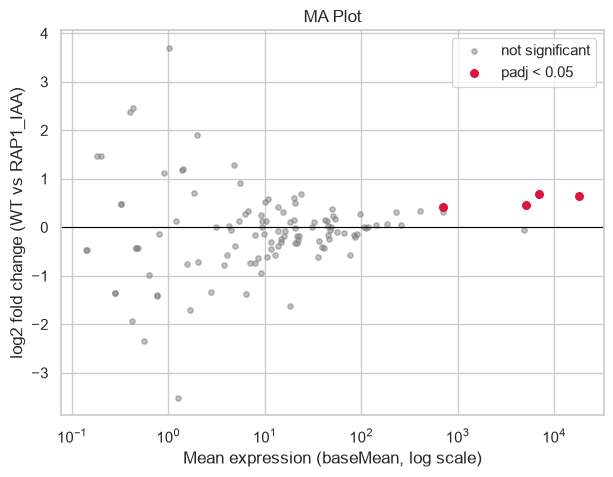

In [12]:
# Split genes into significant vs not, so they can be colored differently —
# and so the significant points get drawn last (on top).
sig = results["padj"] < 0.05

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    results.loc[~sig, "baseMean"], results.loc[~sig, "log2FoldChange"],
    s=15, alpha=0.5, color="grey", label="not significant",
)
ax.scatter(
    results.loc[sig, "baseMean"], results.loc[sig, "log2FoldChange"],
    s=30, color="crimson", label="padj < 0.05",
)

ax.set_xscale("log")  # baseMean spans several orders of magnitude (0 to 18,000+)
ax.axhline(0, color="black", linewidth=0.8)  # reference line: no fold change at all
ax.set_xlabel("Mean expression (baseMean, log scale)")
ax.set_ylabel("log2 fold change (WT vs RAP1_IAA)")
ax.set_title("MA Plot")
ax.legend()
plt.show()

### Volcano Plot

log2 fold change (x-axis) vs statistical significance (-log10(padj), y-axis) — combining effect size and confidence into one plot, which neither the MA plot nor a plain results table does on its own. Points toward the upper-left/upper-right corners are the ones that matter most: large effect *and* high confidence, simultaneously. Recall the sign convention from Section 2: positive log2FC means higher in `WT`, negative means higher in `RAP1_IAA`.

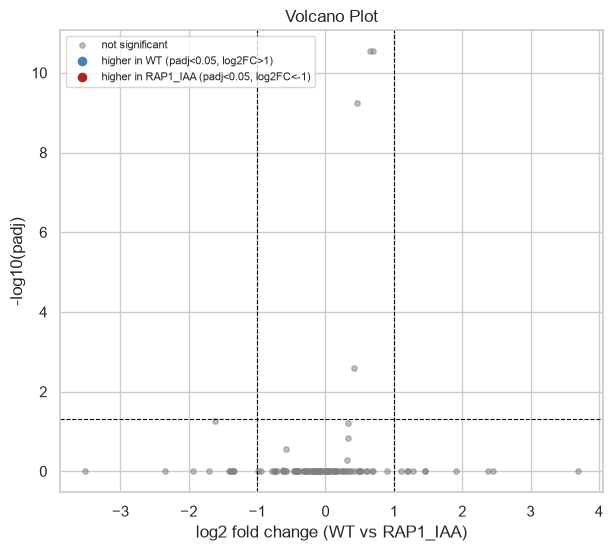

In [13]:
plot_df = results.copy()
plot_df["neg_log10_padj"] = -np.log10(plot_df["padj"])

# Two significance thresholds combined: padj < 0.05 (confidence) AND
# |log2FC| > 1 (a real, meaningful effect size — a 2x change or more),
# split by direction so up/down can be colored separately.
higher_in_wt = (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] > 1)
higher_in_rap1 = (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] < -1)
not_sig = ~(higher_in_wt | higher_in_rap1)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df.loc[not_sig, "log2FoldChange"], plot_df.loc[not_sig, "neg_log10_padj"],
    s=15, alpha=0.5, color="grey", label="not significant",
)
ax.scatter(
    plot_df.loc[higher_in_wt, "log2FoldChange"], plot_df.loc[higher_in_wt, "neg_log10_padj"],
    s=35, color="steelblue", label="higher in WT (padj<0.05, log2FC>1)",
)
ax.scatter(
    plot_df.loc[higher_in_rap1, "log2FoldChange"], plot_df.loc[higher_in_rap1, "neg_log10_padj"],
    s=35, color="firebrick", label="higher in RAP1_IAA (padj<0.05, log2FC<-1)",
)

# Reference lines marking the significance/effect-size cutoffs used above,
# so the plot visually explains its own coloring.
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="black", linestyle="--", linewidth=0.8)

ax.set_xlabel("log2 fold change (WT vs RAP1_IAA)")
ax.set_ylabel("-log10(padj)")
ax.set_title("Volcano Plot")
ax.legend(fontsize=8, loc="upper left")
plt.show()

### Heatmap of Significant Genes

A heatmap of the genes that actually matter — the 4 significant DE genes, not all 124 — showing every sample's expression pattern side by side. Each gene is **z-scored** (its own mean subtracted, divided by its own standard deviation) across samples first: this puts every gene on the same relative scale, so the heatmap shows "which genes go up or down together across samples" rather than just "which genes have naturally higher raw counts" (not interesting on its own — a highly-expressed gene isn't more biologically important than a lowly-expressed one).

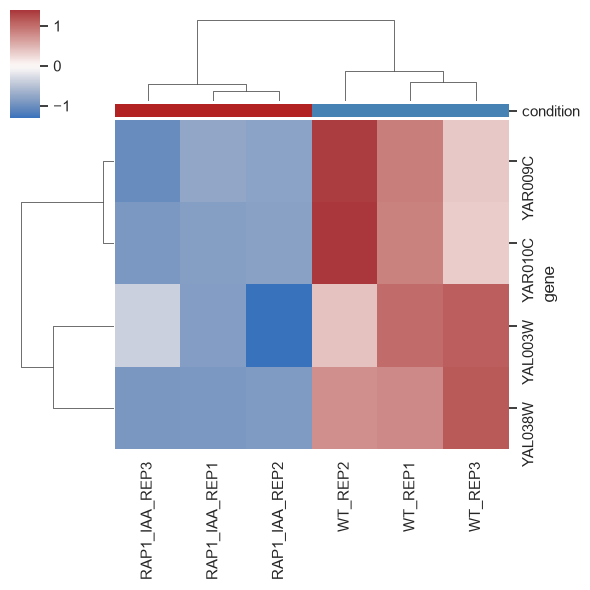

In [14]:
sig_genes = results[results["padj"] < 0.05].index

# log2 first (same rationale as Section 4's PCA), then z-score each gene
# (row) across the 6 samples so every gene sits on a comparable scale.
log_sig_counts = np.log2(counts.loc[sig_genes] + 1)
z_scored = log_sig_counts.sub(log_sig_counts.mean(axis=1), axis=0).div(log_sig_counts.std(axis=1), axis=0)

# Color-code each sample column by its condition, so the heatmap's column
# order (after clustering) can be visually checked against the known groups.
condition_colors = samples.set_index("sample")["condition"].map({"WT": "steelblue", "RAP1_IAA": "firebrick"})
condition_colors = condition_colors.reindex(z_scored.columns)

sns.clustermap(
    z_scored, cmap="vlag", center=0,   # diverging colormap centered on 0 (the z-scored mean)
    col_colors=condition_colors,
    figsize=(6, 6), yticklabels=True,
)
plt.show()

**What to check:** with just 4 genes, this heatmap should split cleanly into two blocks — genes that read yellow/red (above their own mean) in `WT` and blue (below their own mean) in `RAP1_IAA`, or the reverse — since all 4 were selected specifically for being confidently different between conditions. The column dendrogram at the top is another chance to check whether the 6 samples cluster into their two condition groups, this time using only the genes known to actually differ (unlike Section 4's clustermap, which used all 124 genes and didn't separate as cleanly for exactly that reason).